<a href="https://colab.research.google.com/github/31Rishita/Crop_Yield_Prediction_and_Recommendation/blob/main/BiLSTM_Crop_Yield_Prediction_and_Recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pickle

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


In [9]:
# Cell 2: Load dataset (tries common paths; falls back to Colab upload)
possible_paths = [
    '/content/merged_crop_yield_dataset.csv',
    '/mnt/data/merged_crop_yield_dataset.csv',
    './merged_crop_yield_dataset.csv',
    '/'
]

csv_path = None
for p in possible_paths:
    if os.path.isdir(p):
        # skip directories
        continue
    if os.path.exists(p) and os.path.isfile(p):
        csv_path = p
        break

if csv_path is None:
    # If in Colab, prompt upload
    try:
        from google.colab import files
        print("Please upload your CSV file (e.g., merged_crop_yield_dataset.csv)")
        uploaded = files.upload()
        if len(uploaded) > 0:
            csv_path = list(uploaded.keys())[0]
    except Exception as e:
        pass

if csv_path is None:
    raise FileNotFoundError("Dataset not found. Upload merged_crop_yield_dataset.csv into Colab or place in /content or /mnt/data.")

print("Loading dataset from:", csv_path)
df = pd.read_csv(csv_path)
print("Dataframe loaded. Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Loading dataset from: /content/merged_crop_yield_dataset.csv
Dataframe loaded. Shape: (19689, 16)
Columns: ['crop', 'year', 'season', 'state', 'area', 'production', 'fertilizer', 'pesticide', 'yield', 'avg_temp_c', 'total_rainfall_mm', 'avg_humidity_percent', 'N', 'P', 'K', 'pH']


,crop,year,season,state,area,production,fertilizer,pesticide,yield,avg_temp_c,total_rainfall_mm,avg_humidity_percent,N,P,K,pH
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,7024878.38,22882.34,0.796087,22.41,1468.92,70.71,60,18,38,5.8
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,631643.29,2057.47,0.710435,22.41,1468.92,70.71,60,18,38,5.8
2,Castor seed,1997,Kharif,Assam,796.0,22,75755.32,246.76,0.238333,22.41,1468.92,70.71,60,18,38,5.8
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,1870661.52,6093.36,5238.051739,22.41,1468.92,70.71,60,18,38,5.8
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,165500.63,539.09,0.420909,22.41,1468.92,70.71,60,18,38,5.8


In [10]:
# Cell 3: Basic normalization and yield creation (if needed)
df.columns = [c.strip() for c in df.columns]

# Detect production/area/yield columns
col_lower = {c.lower(): c for c in df.columns}
production_col = None
area_col = None
yield_col = None
for k, v in col_lower.items():
    if 'production' in k:
        production_col = v
    if 'area' in k:
        area_col = v
    if k == 'yield' or 'yield' in k:
        yield_col = v

if yield_col is None and production_col is not None and area_col is not None:
    df['yield'] = df[production_col] / df[area_col].replace({0: np.nan})
    print("Created 'yield' as Production/Area.")
elif yield_col is not None:
    df['yield'] = df[yield_col]
else:
    raise RuntimeError("Couldn't find production/area/yield columns. Please ensure your CSV contains production and area or yield.")

# Detect time column (year/date)
time_col = None
for k, v in col_lower.items():
    if 'year' in k or 'date' in k:
        time_col = v
        break

if time_col is None:
    df['Year'] = pd.RangeIndex(start=1, stop=len(df)+1)
    time_col = 'Year'
    print("No explicit year/date column found — created artificial 'Year' index.")
else:
    print("Found time column:", time_col)

# Ensure numeric time where possible
try:
    df[time_col] = pd.to_numeric(df[time_col], errors='coerce')
    if df[time_col].isna().all():
        df[time_col] = pd.to_datetime(df[time_col], errors='coerce').dt.year
except Exception:
    df[time_col] = pd.to_datetime(df[time_col], errors='coerce').dt.year

# Detect crop column
crop_col = None
for c in df.columns:
    if c.lower() in ('crop', 'crop_name', 'cropname'):
        crop_col = c
        break
if crop_col is None:
    # heuristic to pick a likely categorical column for crops
    for c in df.columns:
        if df[c].dtype == object and 2 < df[c].nunique() < 400:
            crop_col = c
            break
if crop_col is None:
    raise RuntimeError("Could not detect a crop column — please ensure your CSV has a crop name column.")
print("Using crop column:", crop_col)

# Create/derive a location key from state/district if available
loc_cols = [c for c in df.columns if c.lower() in ('state', 'district', 'region')]
if len(loc_cols) == 0:
    df['location'] = 'loc_0'
    print("No location columns found — created synthetic 'location'.")
else:
    df['location'] = df[loc_cols].astype(str).agg('__'.join, axis=1)
    print("Derived 'location' from:", loc_cols)

df.head(3)


Found time column: year
Using crop column: crop
Derived 'location' from: ['state']


,crop,year,season,state,area,production,fertilizer,pesticide,yield,avg_temp_c,total_rainfall_mm,avg_humidity_percent,N,P,K,pH,location
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,7024878.38,22882.34,0.796087,22.41,1468.92,70.71,60,18,38,5.8,Assam
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,631643.29,2057.47,0.710435,22.41,1468.92,70.71,60,18,38,5.8,Assam
2,Castor seed,1997,Kharif,Assam,796.0,22,75755.32,246.76,0.238333,22.41,1468.92,70.71,60,18,38,5.8,Assam


In [11]:
# Cell 4: Remove duplicate column labels (keep first occurrence) and prepare columns
df = df.loc[:, ~df.columns.duplicated()]  # drop duplicate-labeled columns (keeps first)
print("Columns after removing duplicates:", df.columns.tolist())

# essential columns
essential_cols = ['location', crop_col, time_col, 'yield']
# detect environmental/soil features heuristically
possible_features = ['N', 'P', 'K', 'nitrogen', 'phosphorus', 'potassium',
                     'rainfall', 'rain', 'temperature', 'temp', 'humidity', 'soil_pH', 'ph',
                     'fertilizer', 'fertilizer_usage', 'total_rainfall', 'avg_temp', 'production', 'pesticide', 'avg_temp_c', 'total_rainfall_mm', 'avg_humidity_percent']
features_found = []
for feat in possible_features:
    for c in df.columns:
        if feat.lower() == c.lower() or feat.lower() in c.lower():
            if c not in essential_cols:
                features_found.append(c)
features_found = list(dict.fromkeys(features_found))
print("Detected environmental/soil features:", features_found)

# final modeling features (include time as feature too)
model_features = features_found.copy()
if time_col not in model_features:
    model_features.append(time_col)

# create df_model with unique columns while preserving order
cols_for_model = essential_cols + [c for c in model_features if c not in essential_cols]
df_model = df[cols_for_model].copy()
print("Columns used for modeling (no duplicates):", df_model.columns.tolist())
print("Shape:", df_model.shape)


Columns after removing duplicates: ['crop', 'year', 'season', 'state', 'area', 'production', 'fertilizer', 'pesticide', 'yield', 'avg_temp_c', 'total_rainfall_mm', 'avg_humidity_percent', 'N', 'P', 'K', 'pH', 'location']
Detected environmental/soil features: ['season', 'production', 'total_rainfall_mm', 'avg_humidity_percent', 'N', 'pesticide', 'avg_temp_c', 'P', 'pH', 'K', 'fertilizer']
Columns used for modeling (no duplicates): ['location', 'crop', 'year', 'yield', 'season', 'production', 'total_rainfall_mm', 'avg_humidity_percent', 'N', 'pesticide', 'avg_temp_c', 'P', 'pH', 'K', 'fertilizer']
Shape: (19689, 15)


In [12]:
# Cell 5: Encode crop and location columns
le_crop = LabelEncoder()
df_model['crop_code'] = le_crop.fit_transform(df_model[crop_col].astype(str))

le_loc = LabelEncoder()
df_model['loc_code'] = le_loc.fit_transform(df_model['location'].astype(str))

print("Number of unique crops detected:", df_model['crop_code'].nunique())
print("Added encoded columns: crop_code and loc_code")


Number of unique crops detected: 55
Added encoded columns: crop_code and loc_code


In [13]:
# Cell 6: Encode any non-numeric features in model_features and coerce numeric
print("model_features (before):", model_features)

non_numeric_feats = [c for c in model_features if df_model[c].dtype == object or df_model[c].dtype.name == 'category']
print("Non-numeric features detected (to be label-encoded):", non_numeric_feats)

label_encoders = {}
for feat in non_numeric_feats:
    le = LabelEncoder()
    new_col = feat + "_code"
    df_model[new_col] = le.fit_transform(df_model[feat].astype(str))
    label_encoders[feat] = le
    # replace name in model_features list
    idx = model_features.index(feat)
    model_features[idx] = new_col

# Coerce all model_features to numeric and fill NaNs with median
for feat in model_features:
    df_model[feat] = pd.to_numeric(df_model[feat], errors='coerce')
    if df_model[feat].isna().any():
        med = df_model[feat].median()
        df_model[feat] = df_model[feat].fillna(med)
        print(f"Filled NaNs in {feat} with median {med}")

print("model_features (after):", model_features)
print(df_model[model_features].dtypes)
df_model.head(3)


model_features (before): ['season', 'production', 'total_rainfall_mm', 'avg_humidity_percent', 'N', 'pesticide', 'avg_temp_c', 'P', 'pH', 'K', 'fertilizer', 'year']
Non-numeric features detected (to be label-encoded): ['season']
model_features (after): ['season_code', 'production', 'total_rainfall_mm', 'avg_humidity_percent', 'N', 'pesticide', 'avg_temp_c', 'P', 'pH', 'K', 'fertilizer', 'year']
season_code               int64
production                int64
total_rainfall_mm       float64
avg_humidity_percent    float64
N                         int64
pesticide               float64
avg_temp_c              float64
P                         int64
pH                      float64
K                         int64
fertilizer              float64
year                      int64
dtype: object


,location,crop,year,yield,season,production,total_rainfall_mm,avg_humidity_percent,N,pesticide,avg_temp_c,P,pH,K,fertilizer,crop_code,loc_code,season_code
0,Assam,Arecanut,1997,0.796087,Whole Year,56708,1468.92,70.71,60,22882.34,22.41,18,5.8,38,7024878.38,0,2,4
1,Assam,Arhar/Tur,1997,0.710435,Kharif,4685,1468.92,70.71,60,2057.47,22.41,18,5.8,38,631643.29,1,2,1
2,Assam,Castor seed,1997,0.238333,Kharif,22,1468.92,70.71,60,246.76,22.41,18,5.8,38,75755.32,8,2,1


In [14]:
# Cell 7: Create rolling sequences grouped by (location, crop)
window_size = 3  # number of past timesteps used
horizon = 1      # predict next-step yield

X_list = []
y_list = []
meta = []

# We will include crop_code as a feature in the sequence
feature_cols_for_model = model_features + ['crop_code']

# Fill missing model feature values within groups
for (loc, crop), group in df_model.groupby(['location', crop_col]):
    g = group.sort_values(by=time_col).reset_index(drop=True)
    # forward/backfill within group for model_features
    g[model_features] = g[model_features].ffill().bfill()
    if len(g) >= window_size + horizon:
        for start in range(0, len(g) - window_size - horizon + 1):
            window = g.iloc[start:start+window_size]
            target = g.iloc[start+window_size + (horizon-1)]['yield']
            # ensure crop_code exists in this window
            if 'crop_code' not in window.columns:
                continue
            try:
                arr = window[feature_cols_for_model].to_numpy(dtype=float)
            except Exception as e:
                # If conversion fails, coerce and fill
                arr = window[feature_cols_for_model].apply(pd.to_numeric, errors='coerce').fillna(0.0).to_numpy(dtype=float)
            X_list.append(arr)
            y_list.append(target)
            meta.append({'location': loc, 'crop': crop, 'last_time': window[time_col].iloc[-1]})

if len(X_list) == 0:
    raise RuntimeError("No training sequences created. Try reducing window_size or check dataset coverage.")

X = np.array(X_list)   # shape: (samples, timesteps, features)
y = np.array(y_list).reshape(-1, 1)
print("Created sequences: X shape =", X.shape, ", y shape =", y.shape)


Created sequences: X shape = (16788, 3, 13) , y shape = (16788, 1)


In [15]:
# Cell 8: Scaling and train/test split
nsamples, ntimesteps, nvars = X.shape
X_flat = X.reshape(-1, nvars)  # flatten timesteps for scaler

scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_flat).reshape(nsamples, ntimesteps, nvars)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)

# train/test split with metadata
X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X_scaled, y_scaled, meta, test_size=0.15, random_state=42)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (14269, 3, 13) Test shape: (2519, 3, 13)


In [16]:
# Cell 9: Build BiLSTM model
tf.keras.backend.clear_session()

seq_input = Input(shape=(ntimesteps, nvars), name='seq_input')
x = Bidirectional(LSTM(64, return_sequences=False))(seq_input)
x = Dropout(0.2)(x)
x = Dense(32, activation='relu')(x)
output = Dense(1, activation='linear', name='yield_pred')(x)

model = Model(seq_input, output)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ seq_input (InputLayer)          │ (None, 3, 13)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        39,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ yield_pred (Dense)              │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,097 (172.25 KB)

 Trainable params: 44,097 (172.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


379/379 - 7s - 19ms/step - loss: 0.5140 - mae: 0.1677 - val_loss: 0.1696 - val_mae: 0.1397
Epoch 2/100


379/379 - 2s - 4ms/step - loss: 0.1951 - mae: 0.0977 - val_loss: 0.1005 - val_mae: 0.0644
Epoch 3/100
379/379 - 1s - 4ms/step - loss: 0.1444 - mae: 0.0749 - val_loss: 0.1177 - val_mae: 0.0489
Epoch 4/100
379/379 - 1s - 4ms/step - loss: 0.1088 - mae: 0.0610 - val_loss: 0.1122 - val_mae: 0.0447
Epoch 5/100


379/379 - 2s - 4ms/step - loss: 0.0888 - mae: 0.0507 - val_loss: 0.0742 - val_mae: 0.0378
Epoch 6/100


379/379 - 3s - 8ms/step - loss: 0.0755 - mae: 0.0444 - val_loss: 0.0582 - val_mae: 0.0417
Epoch 7/100


...

379/379 - 2s - 6ms/step - loss: 0.0602 - mae: 0.0276 - val_loss: 0.0287 - val_mae: 0.0189
Epoch 14/100
379/379 - 1s - 4ms/step - loss: 0.0352 - mae: 0.0240 - val_loss: 0.0983 - val_mae: 0.0211
Epoch 15/100
379/379 - 3s - 7ms/step - loss: 0.0555 - mae: 0.0252 - val_loss: 0.0358 - val_mae: 0.0179
Epoch 16/100
379/379 - 1s - 4ms/step - loss: 0.0413 - mae: 0.0219 - val_loss: 0.0889 - val_mae: 0.0247
Epoch 17/100
379/379 - 2s - 4ms/step - loss: 0.0359 - mae: 0.0216 - val_loss: 0.0992 - val_mae: 0.0284
Epoch 18/100
379/379 - 1s - 4ms/step - loss: 0.0489 - mae: 0.0232 - val_loss: 0.0590 - val_mae: 0.0168
Epoch 19/100


379/379 - 3s - 7ms/step - loss: 0.0361 - mae: 0.0207 - val_loss: 0.0191 - val_mae: 0.0152
Epoch 20/100
379/379 - 4s - 11ms/step - loss: 0.0630 - mae: 0.0245 - val_loss: 0.0380 - val_mae: 0.0177
Epoch 21/100
379/379 - 2s - 4ms/step - loss: 0.0337 - mae: 0.0213 - val_loss: 0.0226 - val_mae: 0.0155
Epoch 22/100


379/379 - 2s - 4ms/step - loss: 0.0278 - mae: 0.0199 - val_loss: 0.0163 - val_mae: 0.0144
Epoch 23/100
379/379 - 2s - 4ms/step - loss: 0.0196 - mae: 0.0183 - val_loss: 0.0388 - val_mae: 0.0160
Epoch 24/100
379/379 - 2s - 4ms/step - loss: 0.0213 - mae: 0.0192 - val_loss: 0.0174 - val_mae: 0.0125
Epoch 25/100
379/379 - 3s - 7ms/step - loss: 0.1063 - mae: 0.0393 - val_loss: 0.0261 - val_mae: 0.0251
Epoch 26/100
379/379 - 1s - 4ms/step - loss: 0.0223 - mae: 0.0263 - val_loss: 0.0972 - val_mae: 0.0195
Epoch 27/100
379/379 - 1s - 4ms/step - loss: 0.0388 - mae: 0.0250 - val_loss: 0.0261 - val_mae: 0.0173
Epoch 28/100
379/379 - 1s - 4ms/step - loss: 0.0148 - mae: 0.0183 - val_loss: 0.0204 - val_mae: 0.0150
Epoch 29/100


379/379 - 2s - 4ms/step - loss: 0.0193 - mae: 0.0191 - val_loss: 0.0157 - val_mae: 0.0141
Epoch 30/100


379/379 - 3s - 7ms/step - loss: 0.0176 - mae: 0.0183 - val_loss: 0.0131 - val_mae: 0.0149
Epoch 31/100
379/379 - 2s - 4ms/step - loss: 0.0207 - mae: 0.0184 - val_loss: 0.0215 - val_mae: 0.0172
Epoch 32/100
379/379 - 2s - 6ms/step - loss: 0.0147 - mae: 0.0163 - val_loss: 0.0221 - val_mae: 0.0148
Epoch 33/100
379/379 - 1s - 4ms/step - loss: 0.0159 - mae: 0.0168 - val_loss: 0.0251 - val_mae: 0.0152
Epoch 34/100
379/379 - 2s - 4ms/step - loss: 0.0171 - mae: 0.0178 - val_loss: 0.0991 - val_mae: 0.0204
Epoch 35/100
379/379 - 1s - 4ms/step - loss: 0.1367 - mae: 0.0485 - val_loss: 0.0630 - val_mae: 0.0424
Epoch 36/100
379/379 - 2s - 4ms/step - loss: 0.0637 - mae: 0.0564 - val_loss: 0.1020 - val_mae: 0.0648
Epoch 37/100
379/379 - 2s - 4ms/step - loss: 0.1733 - mae: 0.0723 - val_loss: 0.0806 - val_mae: 0.0645
Epoch 38/100
379/379 - 1s - 4ms/step - loss: 0.0169 - mae: 0.0371 - val_loss: 0.0304 - val_mae: 0.0203
Epoch 39/100
379/379 - 2s - 5ms/step - loss: 0.0157 - mae: 0.0293 - val_loss: 0.0180 -

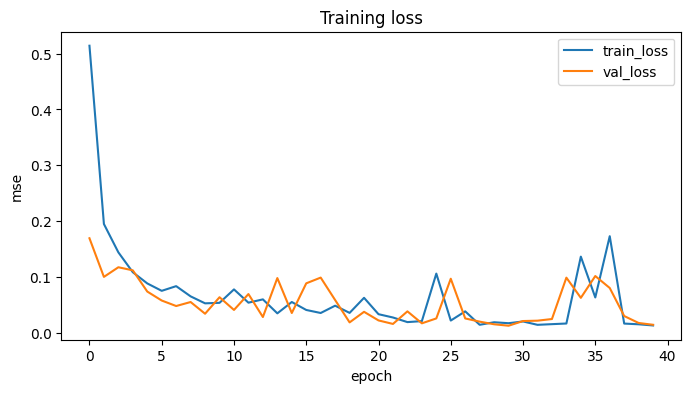

In [17]:
# Cell 10: Train model
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
ckpt_path = 'best_bilstm_model.h5'
mc = ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=100,
    batch_size=32,
    callbacks=[es, mc],
    verbose=2
)

# Plot training history
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('epoch'); plt.ylabel('mse'); plt.legend(); plt.title('Training loss')
plt.show()


Test MSE, MAE: [0.029477842152118683, 0.020058510825037956]
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


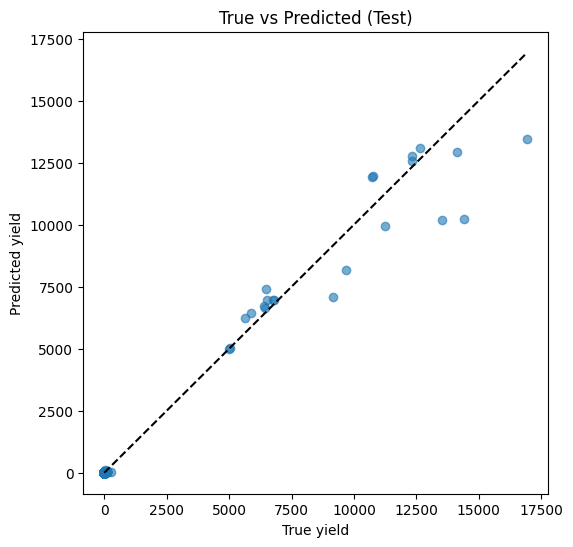

Saved model and preprocessing objects.


In [19]:
# Cell 11: Evaluate on test set, save model and preprocessors
eval_res = model.evaluate(X_test, y_test, verbose=0)
print("Test MSE, MAE:", eval_res)

y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.6)
mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], 'k--')
plt.xlabel('True yield'); plt.ylabel('Predicted yield'); plt.title('True vs Predicted (Test)')
plt.show()

# Save model and preprocessing objects
model.save('bilstm_crop_yield_model.keras')
with open('scaler_X.pkl', 'wb') as f: pickle.dump(scaler_X, f)
with open('scaler_y.pkl', 'wb') as f: pickle.dump(scaler_y, f)
with open('le_crop.pkl', 'wb') as f: pickle.dump(le_crop, f)
with open('le_loc.pkl', 'wb') as f: pickle.dump(le_loc, f)
with open('label_encoders.pkl', 'wb') as f: pickle.dump(label_encoders, f)
print("Saved model and preprocessing objects.")


In [20]:
# Cell 12: Recommendation function (uses saved scalers/le)
import numpy as np

def recommend_crops(current_features: dict, location: str = None, k: int = 5):
    """
    current_features: dict mapping feature names (original feature names, e.g., 'N', 'total_rainfall_mm', 'season', 'year', ...) to values
    location: optional string (must match df_model['location'] values). If not provided, will synthesize a baseline sequence from current_features.
    k: number of crop recommendations to return.
    """
    # Load objects (we already have them in memory; use saved ones if needed)
    _scaler_X = scaler_X
    _scaler_y = scaler_y
    _le_crop = le_crop
    _le_loc = le_loc
    _label_encoders = label_encoders  # may be empty if no non-numeric features

    crops = _le_crop.classes_

    # Build baseline sequence: try to find last sequence for that location in df_model
    baseline_seq = None
    if location is not None and location in df_model['location'].values:
        sub = df_model[df_model['location'] == location].sort_values(time_col)
        last = sub.tail(window_size)[model_features + ['crop_code']]
        if len(last) == window_size:
            baseline_seq = last.to_numpy(dtype=float)

    if baseline_seq is None:
        # synthesize baseline by repeating current_features (respecting encoded names)
        arr = []
        for _ in range(window_size):
            row = []
            for feat in model_features:
                # if the feature was label-encoded (e.g., 'season_code'), map from original name if provided
                if feat.endswith('_code'):
                    orig = feat[:-5]
                    if orig in current_features:
                        # if original provided as string category, convert using label encoder if available
                        val = current_features[orig]
                        le = _label_encoders.get(orig)
                        if le is not None:
                            try:
                                # if val matches a class string, transform; else if numeric, use directly
                                val_enc = float(le.transform([str(val)])[0])
                                row.append(val_enc)
                                continue
                            except Exception:
                                pass
                        # fallback numeric
                        row.append(float(current_features.get(orig, 0.0)))
                    else:
                        row.append(float(current_features.get(feat, 0.0)))
                else:
                    row.append(float(current_features.get(feat, 0.0)))
            # placeholder crop_code (will be set per-crop)
            row.append(0.0)
            arr.append(row)
        baseline_seq = np.array(arr)

    results = []
    for i, crop_name in enumerate(crops):
        seq_copy = baseline_seq.copy()
        # set crop_code column (last column in our feature_cols_for_model)
        seq_copy[:, -1] = float(_le_crop.transform([crop_name])[0])
        # scale (scaler expects flattened timesteps)
        nvars_local = seq_copy.shape[1]
        seq_flat = seq_copy  # shape (timesteps, nvars)
        seq_scaled = _scaler_X.transform(seq_flat).reshape(1, window_size, nvars_local)
        pred_scaled = model.predict(seq_scaled, verbose=0)
        pred = _scaler_y.inverse_transform(pred_scaled.reshape(-1,1))[0,0]
        results.append((crop_name, float(pred)))

    results_sorted = sorted(results, key=lambda x: x[1], reverse=True)
    return results_sorted[:k]

# Example usage:
example_current = {}
# Try to provide values for the features present in model_features. For example:
for f in model_features:
    # set reasonable defaults if you don't supply them
    example_current[f] = float(df_model[f].median()) if f in df_model.columns else 0.0

print("Top 5 recommended crops for current median conditions:")
print(recommend_crops(example_current, location=None, k=5))


Top 5 recommended crops for current median conditions:
[('other oilseeds', 15.826904296875), ('Wheat', 15.710445404052734), ('Urad', 15.583301544189453), ('Turmeric', 15.444904327392578), ('Tobacco', 15.29476547241211)]


Test set metrics:
  MSE  : 22410.8970
  RMSE : 149.7027
  MAE  : 17.4896
  MAPE : 6853219.11%
  R^2  : 0.9747


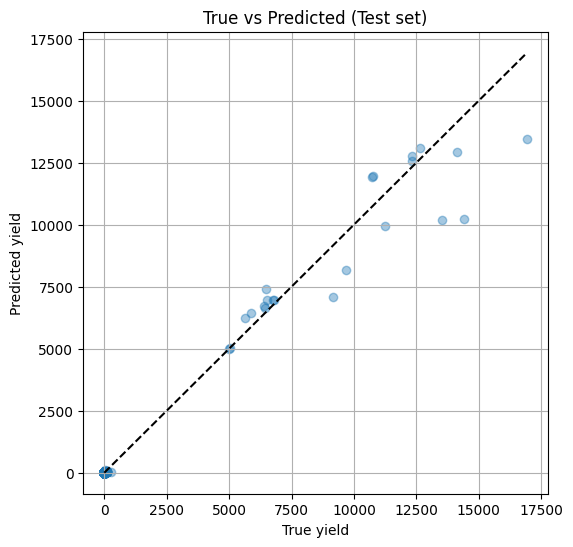

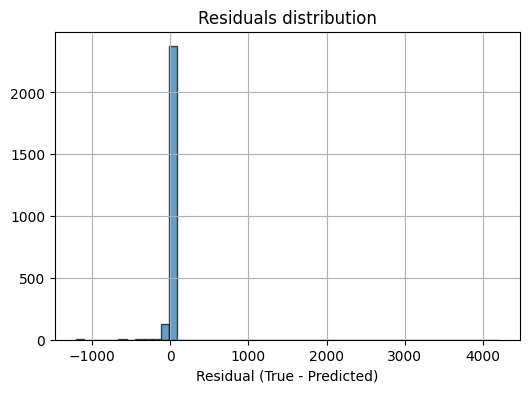


Per-crop summary (top crops by sample count):


,samples,true_mean,pred_mean,mae
crop,,,,
Rice,167,2.271360,9.478651,7.432267
Maize,123,2.418120,5.894566,4.103588
Groundnut,96,1.438138,5.924610,4.711289
Urad,88,0.608985,10.650871,10.104297
Sesamum,83,0.511882,10.123055,9.611174
Potato,82,12.596656,14.955553,5.402621
Moong(Green Gram),80,0.565171,7.605077,7.039906
Gram,79,0.949482,6.212036,5.352371
Wheat,76,2.009422,10.829709,8.851965


In [21]:
# === Cell: Evaluate model properly and show useful metrics & plots ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Use previously computed y_true, y_pred if available; otherwise compute from X_test
try:
    y_true = scaler_y.inverse_transform(y_test)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
except Exception:
    # if y_pred_scaled not present, generate predictions
    y_pred_scaled = model.predict(X_test)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_true = scaler_y.inverse_transform(y_test)

# Flatten arrays
y_true = y_true.reshape(-1)
y_pred = y_pred.reshape(-1)

# Metrics
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
# Avoid division by zero in MAPE
mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true==0, 1e-6, y_true))) * 100

print("Test set metrics:")
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"  MAPE : {mape:.2f}%")
print(f"  R^2  : {r2:.4f}")

# Scatter: True vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.4)
mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], 'k--')
plt.xlabel("True yield")
plt.ylabel("Predicted yield")
plt.title("True vs Predicted (Test set)")
plt.grid(True)
plt.show()

# Residuals histogram
residuals = y_true - y_pred
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=50, edgecolor='k', alpha=0.7)
plt.xlabel("Residual (True - Predicted)")
plt.title("Residuals distribution")
plt.grid(True)
plt.show()

# Optional: Per-crop summary (average true vs predicted)
# meta_test is a list of dicts for each X_test sample (if you kept it during train_test_split)
try:
    import pandas as pd
    df_meta_test = pd.DataFrame(meta_test)
    df_meta_test['y_true'] = y_true
    df_meta_test['y_pred'] = y_pred
    # group by crop and show top 10 crops by sample count
    crop_counts = df_meta_test['crop'].value_counts().head(10).index.tolist()
    summary = df_meta_test[df_meta_test['crop'].isin(crop_counts)].groupby('crop').agg(
        samples=('y_true', 'size'),
        true_mean=('y_true', 'mean'),
        pred_mean=('y_pred', 'mean'),
        mae=('y_true', lambda x: np.mean(np.abs(x - df_meta_test.loc[x.index, 'y_pred'])))
    ).sort_values('samples', ascending=False)
    print("\nPer-crop summary (top crops by sample count):")
    display(summary)
except Exception as e:
    print("Per-crop summary skipped (meta_test not available or error):", e)


In [27]:
# ----------------- Compute Total Production (from predicted yield) -----------------
import numpy as np
import pandas as pd
import math

# Inputs assumed present from previous cells:
# - pred_yield (predicted per-area yield for chosen_crop)
# - chosen_crop (string)
# - chosen_location (string)
# - recs (list of tuples [(crop_name, predicted_yield), ...])
# - df (original full dataframe)
# - df_model (processed df used for modeling)

# Optional: if you want to override with a specific area (hectares), set user_area (float).
# If user_area is None, the code will use dataset averages.
user_area = None  # e.g., set to 10.0 if you want total for 10 hectares

def choose_area_for(crop_name, location_name):
    """
    Returns a best-guess area (same units as df['area']) to compute total production.
    Preference order:
      1) mean area for (crop, location)
      2) mean area for crop (all locations)
      3) overall mean area
    """
    # try crop-location
    mask1 = (df['crop'].astype(str).str.strip() == str(crop_name).strip()) & (df['location'].astype(str) == str(location_name))
    if mask1.any():
        a = df.loc[mask1, 'area'].replace({0: np.nan}).dropna()
        if len(a) > 0:
            return float(a.mean())
    # try crop overall
    mask2 = (df['crop'].astype(str).str.strip() == str(crop_name).strip())
    if mask2.any():
        a2 = df.loc[mask2, 'area'].replace({0: np.nan}).dropna()
        if len(a2) > 0:
            return float(a2.mean())
    # fallback overall mean area
    a_all = df['area'].replace({0: np.nan}).dropna()
    if len(a_all) > 0:
        return float(a_all.mean())
    # final fallback: 1 hectare
    return 1.0

# compute for chosen crop
area_for_chosen = user_area if user_area is not None else choose_area_for(chosen_crop, chosen_location)
total_production_chosen = pred_yield * area_for_chosen

print("=== Chosen crop estimate ===")
print(f"Crop: {chosen_crop!s}")
print(f"Location: {chosen_location!s}")
print(f"Per-area predicted yield: {pred_yield:.6g} (same units as df['yield'])")
print(f"Area used for estimate: {area_for_chosen:.3f} (same units as df['area'])")
print(f"Estimated total production = yield × area = {total_production_chosen:,.3f} (same units as df['production'])\n")

# compute for top-k recommendations
print("=== Top recommendations: per-area yield → total production (using best-guess area) ===")
rows = []
for crop_name, pred_y in recs:
    # choose area for that crop (prefer same location)
    area_k = user_area if user_area is not None else choose_area_for(crop_name, chosen_location)
    total_k = pred_y * area_k
    rows.append({
        'crop': crop_name,
        'predicted_yield_per_area': pred_y,
        'area_used': area_k,
        'estimated_total_production': total_k
    })
    print(f"{crop_name:25s} | Yield: {pred_y:.4g} | Area used: {area_k:.3f} | Total production: {total_k:,.3f}")

# Save to CSV for download
out_df = pd.DataFrame(rows)
out_df.to_csv('/content/merged_crop_yield_dataset.csv', index=False)
print("\nSaved production estimates to /content/merged_crop_yield_dataset.csv")

# Helpful note about units
print("\nNOTE on units:")
print("- 'predicted_yield_per_area' is in the same unit as your df['yield'] column (likely t/ha or kg/ha).")
print("- 'area_used' is in the same unit as your df['area'] column (likely hectares).")
print("- 'estimated_total_production' = yield_per_area × area_used (same units as df['production']).")
print("\nIf you want the estimate for a custom area (e.g., number of hectares you own), set user_area = <your area> and re-run this cell.")


=== Chosen crop estimate ===
Crop: Coconut 
Location: Assam
Per-area predicted yield: 1.30634 (same units as df['yield'])
Area used for estimate: 20190.773 (same units as df['area'])
Estimated total production = yield × area = 26,376.002 (same units as df['production'])

=== Top recommendations: per-area yield → total production (using best-guess area) ===
other oilseeds            | Yield: 4.408 | Area used: 6973.357 | Total production: 30,737.182
Wheat                     | Yield: 4.306 | Area used: 49135.696 | Total production: 211,588.228
Urad                      | Yield: 4.205 | Area used: 47273.158 | Total production: 198,791.470
Turmeric                  | Yield: 4.105 | Area used: 13779.435 | Total production: 56,561.314
Tobacco                   | Yield: 4.005 | Area used: 593.957 | Total production: 2,378.756

Saved production estimates to /content/merged_crop_yield_dataset.csv

NOTE on units:
- 'predicted_yield_per_area' is in the same unit as your df['yield'] column (likel

In [25]:
# 🌴 Predict next-step yield specifically for Coconut
import numpy as np

chosen_crop = "Coconut "   # target crop
chosen_location = "Assam" # you can change this to any region in your dataset

# Verify crop exists
if chosen_crop not in le_crop.classes_:
    raise ValueError(f"Crop '{chosen_crop}' not found in your label encoder. Available crops: {list(le_crop.classes_)[:10]} ...")

# Build baseline sequence from existing function
def build_baseline_sequence(current_features, location=None):
    baseline_seq = None
    if location is not None and location in df_model['location'].values:
        sub = df_model[df_model['location'] == location].sort_values(time_col)
        last = sub.tail(window_size)[model_features + ['crop_code']]
        if len(last) == window_size:
            baseline_seq = last.to_numpy(dtype=float)
    if baseline_seq is None:
        arr = []
        for _ in range(window_size):
            row = []
            for feat in model_features:
                if feat.endswith('_code'):
                    orig = feat[:-5]
                    if orig in current_features:
                        val = current_features[orig]
                        le = label_encoders.get(orig)
                        if le is not None:
                            try:
                                row.append(float(le.transform([str(val)])[0]))
                                continue
                            except Exception:
                                pass
                        row.append(float(current_features.get(orig, 0.0)))
                    else:
                        row.append(float(current_features.get(feat, 0.0)))
                else:
                    row.append(float(current_features.get(feat, 0.0)))
            row.append(0.0)
            arr.append(row)
        baseline_seq = np.array(arr)
    return baseline_seq

# Use the same sample_current features from before
seq = build_baseline_sequence(sample_current, location=chosen_location)

# Set crop code for Coconut
seq[:, -1] = float(le_crop.transform([chosen_crop])[0])

# Scale and predict
seq_scaled = scaler_X.transform(seq).reshape(1, window_size, seq.shape[1])
pred_scaled = model.predict(seq_scaled, verbose=0)
pred_yield = float(scaler_y.inverse_transform(pred_scaled.reshape(-1,1))[0,0])

print(f"\nPredicted next-step yield for '{chosen_crop}' at location '{chosen_location}':")
print(f"  Predicted yield = {pred_yield:.3f} (same units as dataset)")

# Convert to total production if desired
avg_area = df[df['crop'] == chosen_crop]['area'].mean()
total_production = pred_yield * avg_area
print(f"  → Approx. total production = {total_production:,.2f} (yield × avg area)")



Predicted next-step yield for 'Coconut ' at location 'Assam':
  Predicted yield = 1.306 (same units as dataset)
  → Approx. total production = 292,053.92 (yield × avg area)
